In [ ]:
# import numpy as np

# def generate_pattern_matrix(X: int) -> np.ndarray:
#     M = np.ones((X, X * 4), dtype=int)
#     base = np.array([128, 64, 32, 16])
#     for i in range(X):
#         M[i, :] *= 1 if i % 2 == 0 else -1
#         start = (i * X) % (X * 4)
#         end = start + 4
#         M[i, start:end] = base
#     for r in range(X):
#         M[r] = np.roll(M[r], r)
#     return M

In [74]:
import numpy as np

def generate_pattern_matrix(X: int) -> np.ndarray:
    M = np.ones((X, X * 4), dtype=int)
    base = np.array([128, 64, 32, 16])
    for i in range(X):
        start = i * 4
        end = start + 4
        M[i, start:end] = base
    return M

In [ ]:
N = 48
W = generate_pattern_matrix(N)

# generate random int vector from 0 to 15 incl  with length N
np.random.seed(0)

X = np.random.randint(0, 16, size=(N,))

print("Input vector X:", X)
out = np.right_shift((X @ W)-np.round((N-1)*7.5).astype(int), 7)
# compute relu
out = np.maximum(out, 0)
print("Output vector Y:", out)


Input vector X: [12 15  5  0  3 11  3  7  9  3  5  2  4  7  6  8  8 12 10  1  6  7  7 14
  8  1  5  9 13  8  9  4  3  0  3  5 14 15 15  0  2  3  8  1  3 13  3  3]
Output vector Y: [11  5  2  0 14  6  3  1  4  1  0  0  0  0  0  0  2  0  0  0 10  4  2  0
  2  0  0  0  6  2  1  0  8  3  1  0  2  0  0  0  4  1  0  0  1  0  0  0
  3  1  0  0  6  2  1  0  5  2  0  0  7  3  1  0  7  3  1  0 11  5  2  0
  9  4  1  0  0  0  0  0  5  2  0  0  6  2  1  0  6  2  1  0 13  6  2  1
  7  3  1  0  0  0  0  0  4  1  0  0  8  3  1  0 12  5  2  1  7  3  1  0
  8  3  1  0  3  1  0  0  2  0  0  0  0  0  0  0  2  0  0  0  4  1  0  0
 13  6  2  1 14  6  3  1 14  6  3  1  0  0  0  0  1  0  0  0  2  0  0  0
  7  3  1  0  0  0  0  0  2  0  0  0 12  5  2  1  2  0  0  0  2  0  0  0]


In [91]:
# gruop out in chunks of 4
out_chunks = out.reshape(-1, 4)
print(out_chunks)

[[11  5  2  0]
 [14  6  3  1]
 [ 4  1  0  0]
 [ 0  0  0  0]
 [ 2  0  0  0]
 [10  4  2  0]
 [ 2  0  0  0]
 [ 6  2  1  0]
 [ 8  3  1  0]
 [ 2  0  0  0]
 [ 4  1  0  0]
 [ 1  0  0  0]
 [ 3  1  0  0]
 [ 6  2  1  0]
 [ 5  2  0  0]
 [ 7  3  1  0]
 [ 7  3  1  0]
 [11  5  2  0]
 [ 9  4  1  0]
 [ 0  0  0  0]
 [ 5  2  0  0]
 [ 6  2  1  0]
 [ 6  2  1  0]
 [13  6  2  1]
 [ 7  3  1  0]
 [ 0  0  0  0]
 [ 4  1  0  0]
 [ 8  3  1  0]
 [12  5  2  1]
 [ 7  3  1  0]
 [ 8  3  1  0]
 [ 3  1  0  0]
 [ 2  0  0  0]
 [ 0  0  0  0]
 [ 2  0  0  0]
 [ 4  1  0  0]
 [13  6  2  1]
 [14  6  3  1]
 [14  6  3  1]
 [ 0  0  0  0]
 [ 1  0  0  0]
 [ 2  0  0  0]
 [ 7  3  1  0]
 [ 0  0  0  0]
 [ 2  0  0  0]
 [12  5  2  1]
 [ 2  0  0  0]
 [ 2  0  0  0]]


In [1]:
from autolightning import auto_main

import yaml

configs = []

with open("./quant_proto_net.yaml", "r") as f:
    proto_config = yaml.safe_load(f)
    configs.append(proto_config)

with open("./few_shot_data.yaml", "r") as f:
    data_config = yaml.safe_load(f)
    configs.append(data_config)

with open(
    "../quant/weight/int_4bit_quant.yaml", "r"
) as f:
    quant_config = yaml.safe_load(f)
    configs.append(quant_config)

from metalarena.configs.machine_specific.lug import config
configs.append(config)

configs[1]["data"]["init_args"]["ways"] = 250
configs[1]["data"]["init_args"]["query_shots"] = 10
configs[1]["data"]["init_args"]["shots"] = 10

configs[1]["data"]["init_args"]["dataloaders"]["pin_memory"] = False

trainer, model, datamodule = auto_main(configs, run=False)

/users/ddenblanken/anaconda3/envs/meta_learning_arena/lib/python3.10/site-packages/lightning/pytorch/cli.py:526: LightningCLI's args parameter is intended to run from within Python like if it were from the command line. To prevent mistakes it is not recommended to provide both args and command line arguments, got: sys.argv[1:]=['--f=/run/user/446686/jupyter/runtime/kernel-v36daf33ea55a8018c77b29b2880c96c91fed857bd.json'], args={'model': {'class_path': 'autolightning.lm.brevitas.BrevitasPrototypical', 'init_args': {'act_quant': {'class_path': 'autolightning.lm.brevitas.quantizer', 'init_args': {'class_paths': ['ShiftedUint8ActPerTensorFixedPoint'], 'init_args': {'bit_width': 4, 'collect_stats_steps': 1500, 'float_to_int_impl_type': {'class_path': 'brevitas.inject.enum.FloatToIntImplType', 'init_args': {'value': 'FLOOR'}}}}}, 'in_quant': {'class_path': 'autolightning.lm.brevitas.quantizer', 'init_args': {'class_paths': ['ShiftedUint8ActPerTensorFixedPoint'], 'init_args': {'bit_width': 4,

In [2]:
import wandb
run = wandb.init()
artifact = run.use_artifact('douwe/test_wandb_lightning/model-snlfy85o:v0', type='model')
artifact_dir = artifact.download()

wandb: Currently logged in as: douwe. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


wandb:   1 of 1 files downloaded.  


In [3]:
path = artifact_dir + "/model.ckpt"

In [4]:
import torch
# load state dict into model.net

with open(path, 'rb') as f:
    checkpoint = torch.load(f)

# Rename all keys that 

model.load_state_dict(checkpoint['state_dict'])
model.eval()
print('---')

---


In [5]:
datamodule.prepare_data()
datamodule.setup('fit')

In [6]:
val_dl = datamodule.val_dataloader()

Getting indices per class: 100%|██████████| 13760/13760 [00:00<00:00, 978512.11it/s]


In [7]:
device = f"cuda:{trainer.device_ids[0]}" if trainer.device_ids else "cpu"

In [11]:
model.net(torch.randn(1, 1, 784).to(device))
print(model.net.quant_net.fc)

AttributeError: 'GraphModule' object has no attribute 'fc'

In [8]:
model.to(device)

import numpy as np

from torch_mate.utils import nested_tuple_to_device

outs = []
num_correct = 0
total_num = 0

for i, batch in enumerate(val_dl):
    batch = nested_tuple_to_device(batch, device)
    out = model.shared_step("val", batch, 0)
    out = out[0].cpu().detach().numpy(), out[1].cpu().detach().numpy()
    num_correct += np.sum(np.argmax(out[0], axis=1) == out[1])
    total_num += out[0].shape[0]
    outs.append(out)
    
    if i == 2:
        break

print(f"Accuracy over {total_num} samples: {num_correct/total_num*100:.2f}%")

/users/ddenblanken/anaconda3/envs/meta_learning_arena/lib/python3.10/site-packages/torch/_tensor.py:1624: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at /pytorch/c10/core/TensorImpl.h:1935.)
  return super().rename(names)
<eval_with_key>.5:25: UserWarning: Defining your `__torch_function__` as a plain method is deprecated and will be an error in future, please define it as a classmethod. (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:316.)
  add_1 = embedder_0_1_temp_layer2_3 + embedder_0_0_act_fn;  embedder_0_1_temp_layer2_3 = embedder_0_0_act_fn = None


Accuracy over 7500 samples: 90.48%


In [53]:
import numpy as np

def get_r_matrix(preds_targets_input, ways, shots):
    R = []

    for repeat in preds_targets_input:
        # split repeat into groups of shots entries, not using numpy
        groups = [repeat[i:i + shots] for i in range(0, len(repeat), shots)]

        R_local = np.zeros((ways, ways))
        
        for group_idx, group_item in enumerate(groups):
            for task_idx in range(len(groups)):
                # print(np.expand_dims(group_item[0][0], axis=0).shape)
                # print(group_item)
                group_preds = [np.expand_dims(group_item[i][0], axis=0).T[:task_idx+1] for i in range(len(group_item))]
                # print(group_preds[0].shape)
                group_preds = np.array(group_preds)[:, :, -1]
                
                # print('--------')

                total = np.sum(np.argmax(group_preds, axis=1) == group_idx)
                R_local[group_idx][task_idx] = total/shots
            
        R.append(R_local)

    # average R over repeats
    R = np.mean(R, axis=0)

    return np.array(R)

In [54]:
# preds_targets = list(zip(out[0], out[1]))
preds_targets = []

for out_entry in outs:
    preds_targets.append(list(zip(out_entry[0], out_entry[1])))

In [55]:
R = get_r_matrix(preds_targets, ways=250, shots=10)

In [30]:
ACC = np.mean(R[:, -1])
print("Final ACC:", ACC)

Final ACC: 0.82528


In [16]:
# Compute 20-shot accuracy for R10 FP32

ACC2 = np.sum(R1, axis=0) / np.arange(1, R1.shape[0] + 1)

print(ACC2[19])

0.9305000000000001


In [56]:
R4 = R

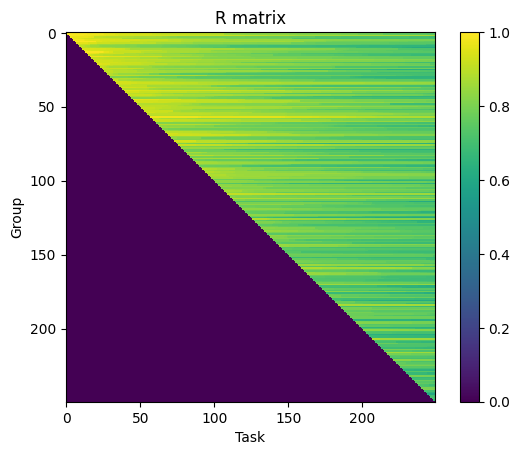

In [18]:
# imshow

import matplotlib.pyplot as plt

plt.imshow(R, interpolation='nearest')
plt.colorbar()
plt.title('R matrix')
plt.xlabel('Task')
plt.ylabel('Group')
plt.show()

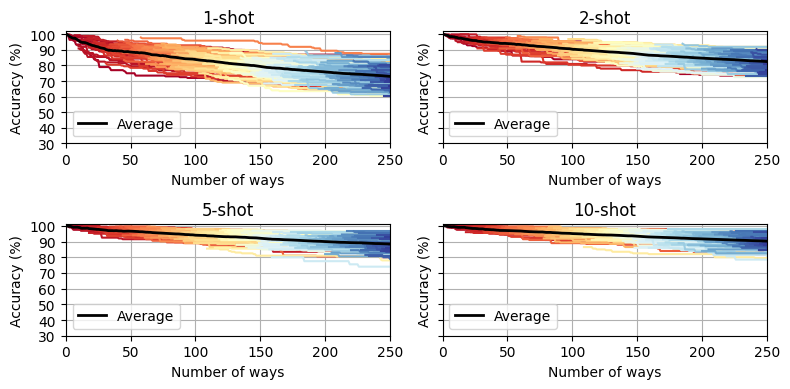

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# load preds_targets from pickle file



def plot_results(R_list: list[np.ndarray]) -> None:
    fig, axs = plt.subplots(2, 2, figsize=(8, 4), sharey='row')
    axs = axs.flatten()

    for idx, (R, ax) in enumerate(zip(R_list, axs)):
        T = R.shape[0]
        cmap = plt.cm.RdYlBu # cool
        colors = [cmap((i + 1) / T) for i in range(T)]

        for i in range(T):
            ax.plot(range(i + 1, T + 1), R[i, :][i:] * 100, color=colors[i])

        avg_curve = np.sum(R, axis=0) / np.arange(1, T + 1)
        ax.plot(range(1,
                      len(avg_curve) + 1),
                avg_curve * 100,
                label="Average",
                color="black",
                linewidth=2)

        shotty = {0: 1, 1: 2, 2: 5, 3: 10}[idx]

        ax.set_title(f"{shotty}-shot")
        # if idx in [2, 3]:
        ax.set_xlabel("Number of ways")
        # if idx % 2 == 0:
        ax.set_ylabel("Accuracy (%)")
        ax.set_yticks(np.arange(30, 101, 10))
        # if idx in [0, 1]: # disable x tick labels
        # ax.set_xticklabels([])
        ax.set_xlim(0, 250)
        ax.grid(True)
        ax.legend(loc='lower left')

    fig.tight_layout()
    fig.savefig("omniglot_10_shot_forgetting_curves_2x2.pdf",
                bbox_inches='tight')
    plt.show()

plot_results([R1, R2, R3, R4])

In [ ]:
import pickle

# save [R1, R2, R3, R4] to pickle file vg3yq0yt

with open('vg3yq0yt_int4_Rmatrices_1_2_5_10_shot.pkl', 'wb') as f:
    pickle.dump([R1, R2, R3, R4], f)

In [58]:
# Compute 20-shot accuracy for R10 FP32

ACC2 = np.sum(R4, axis=0) / np.arange(1, R4.shape[0] + 1)
# ACC2quant = np.sum(R10, axis=0) / np.arange(1, R10.shape[0] + 1)

print(ACC2[19])
# print(ACC2quant[19])

0.9865000000000002
